# 02 — Random Forest y Árbol de Decisión por Cluster
**Random Forest:** captura interacciones no lineales y produce importancias SHAP comparables.  
**Árbol de Decisión:** genera reglas interpretables directamente para cada perfil.

---
El árbol de decisión por cluster produce reglas del tipo:
*"En el Cluster de Primera Generación, un alumno deserta si PNA < 82 Y apoyo_financiero = 0"*

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, recall_score, f1_score, precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)
from sklearn.impute   import SimpleImputer
from sklearn.preprocessing import StandardScaler
import time

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('../../data')
IMG_DIR  = Path('../../data/images/clusters'); IMG_DIR.mkdir(parents=True, exist_ok=True)
CLUSTERED_CSV = DATA_DIR / 'dataset_clustered.csv'

assert CLUSTERED_CSV.exists(), (
    "No se encontró dataset_clustered.csv — ejecutar 00_cluster_profiles.ipynb primero"
)

df = pd.read_csv(CLUSTERED_CSV, low_memory=False)
print(f"✓ dataset_clustered.csv: {df.shape}")

# ── Constantes ────────────────────────────────────────────────────────────────
SEED         = 42
TARGET       = 'retention'
PRETEC21     = ['AD14','AD15','AD16','AD17','AD18']
TEC21        = ['AD19','AD20']
N_CLUSTERS   = df['cluster'].nunique()
MIN_AUC      = 0.60
SKF          = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Features del modelo (excluir fuga y metadatos) ────────────────────────────
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS_BASE = [c for c in [
    'PNA','admission_test_norm','english.evaluation','admission.rubric','general.math.eval',
    'online.test','FTE','apoyo_financiero',
    'has_extracurriculars','has_physical','has_cultural','has_social',
    'first_gen_enc','educ_padres_max','parents_exatec_enc','socioec_enc','social_lag_enc',
    'age','is_male','estuvo_prepa_tec',
    'foreign_Yes: Foreigner','foreign_Yes: National',
    'zone_enc','zone_Rural','zone_Semiurban','zone_Urban',
    'school_enc','region_enc',
    'first_gen_present','parents_edu_present','took_admission_test',
    'has_socioeconomic_data','has_social_lag_data','has_zone_data',
] if c in df.columns and c not in EXCLUDE]

print(f"Features disponibles: {len(FEATURE_COLS_BASE)}")

# ── Paleta de clusters ────────────────────────────────────────────────────────
CLUSTER_COLORS = ['#2563eb','#dc2626','#16a34a','#f59e0b','#7c3aed','#0891b2']

# ── Helper: preparar datos de un cluster ──────────────────────────────────────
def get_cluster_data(cluster_id, regime=None):
    mask = df['cluster'] == cluster_id
    if regime == 'PreTec21':
        mask &= df['generation'].isin(PRETEC21)
    elif regime == 'Tec21':
        mask &= df['generation'].isin(TEC21)
    sub = df[mask].copy()
    feat_cols = [c for c in FEATURE_COLS_BASE if sub[c].std() > 0]
    imp = SimpleImputer(strategy='median')
    X   = imp.fit_transform(sub[feat_cols].values.astype(float))
    y   = sub[TARGET].values.astype(int)
    return X, y, feat_cols, sub

# ── Helper: evaluar modelo ────────────────────────────────────────────────────
def eval_model(model, X, y, model_name, feat_cols, seed=SEED):
    if len(np.unique(y)) < 2 or (y==0).sum() < 5:
        print(f"    ⚠ Insuficientes desertores — omitido")
        return None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:,1] if has_proba else None
    y_pred    = model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if (has_proba and len(np.unique(y_te))>1) else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    return dict(model=model_name, auc=auc, recall=rec, precision=prec, f1=f1,
                y_proba=y_proba, y_pred=y_pred, y_te=y_te, feat_cols=feat_cols,
                n_train=len(y_tr), n_test=len(y_te),
                dropout_rate=(y==0).mean(), trained_model=model)

print("\n✓ Setup completo — listo para entrenar modelos por cluster")

✓ dataset_clustered.csv: (77517, 39)
Features disponibles: 34

✓ Setup completo — listo para entrenar modelos por cluster


## 1. Árbol de Decisión — reglas interpretables por cluster

In [2]:
from sklearn.tree import DecisionTreeClassifier, export_text
try:
    import shap; SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

results_dt = {}

for cluster_id in range(N_CLUSTERS):
    for regime_name, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                               ('Tec21',   ['AD19','AD20'])]:
        key = (cluster_id, regime_name)
        X, y, feat_cols, sub = get_cluster_data(cluster_id, regime_name)
        if (y==0).sum() < 10 or len(y) < 50: continue

        dt = DecisionTreeClassifier(max_depth=4, class_weight='balanced',
                                     min_samples_leaf=10, random_state=SEED)
        res = eval_model(dt, X, y, 'DecisionTree', feat_cols)
        if res is None: continue
        results_dt[key] = res
        print(f"Cluster {cluster_id} [{regime_name}]  AUC={res['auc']:.3f}  "
              f"Recall={res['recall']:.3f}  {'✓' if res['auc']>=MIN_AUC else '⚠'}")

Cluster 0 [PreTec21]  AUC=0.574  Recall=0.479  ⚠
Cluster 0 [Tec21]  AUC=0.597  Recall=0.778  ⚠
Cluster 1 [PreTec21]  AUC=0.611  Recall=0.437  ✓
Cluster 1 [Tec21]  AUC=0.623  Recall=0.591  ✓
Cluster 2 [PreTec21]  AUC=0.611  Recall=0.321  ✓
Cluster 2 [Tec21]  AUC=0.631  Recall=0.681  ✓
Cluster 3 [PreTec21]  AUC=0.614  Recall=0.570  ✓
Cluster 3 [Tec21]  AUC=0.506  Recall=0.970  ⚠


In [3]:
# Imprimir reglas del árbol para cada cluster en PreTec21
print("═══ REGLAS DE ÁRBOL DE DECISIÓN — PreTec21 ═══")
for cluster_id in range(N_CLUSTERS):
    key = (cluster_id, 'PreTec21')
    if key not in results_dt: continue
    res = results_dt[key]
    X, y, feat_cols, _ = get_cluster_data(cluster_id, 'PreTec21')
    dt = res['trained_model']
    print(f"\n{'─'*60}")
    print(f"Cluster {cluster_id}  |  {len(y):,} alumnos  |  {(y==0).mean()*100:.1f}% deserción")
    print(f"AUC={res['auc']:.3f}  Recall={res['recall']:.3f}")
    print("\nReglas (depth=4):")
    print(export_text(dt, feature_names=feat_cols, max_depth=3))

═══ REGLAS DE ÁRBOL DE DECISIÓN — PreTec21 ═══

────────────────────────────────────────────────────────────
Cluster 0  |  20,109 alumnos  |  5.7% deserción
AUC=0.574  Recall=0.479

Reglas (depth=4):
|--- general.math.eval <= 88.73
|   |--- has_cultural <= 0.50
|   |   |--- age <= 20.50
|   |   |   |--- parents_exatec_enc <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- parents_exatec_enc >  0.50
|   |   |   |   |--- class: 1
|   |   |--- age >  20.50
|   |   |   |--- admission_test_norm <= 0.89
|   |   |   |   |--- class: 0
|   |   |   |--- admission_test_norm >  0.89
|   |   |   |   |--- class: 0
|   |--- has_cultural >  0.50
|   |   |--- general.math.eval <= 60.15
|   |   |   |--- age <= 18.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  18.50
|   |   |   |   |--- class: 0
|   |   |--- general.math.eval >  60.15
|   |   |   |--- PNA <= 91.08
|   |   |   |   |--- class: 0
|   |   |   |--- PNA >  91.08
|   |   |   |   |--- class: 1
|--- general.math.eval >  88.73
|   |-


────────────────────────────────────────────────────────────
Cluster 1  |  9,617 alumnos  |  7.1% deserción
AUC=0.611  Recall=0.437

Reglas (depth=4):
|--- apoyo_financiero <= 0.30
|   |--- PNA <= 82.74
|   |   |--- age <= 19.50
|   |   |   |--- general.math.eval <= 92.25
|   |   |   |   |--- class: 0
|   |   |   |--- general.math.eval >  92.25
|   |   |   |   |--- class: 1
|   |   |--- age >  19.50
|   |   |   |--- admission_test_norm <= 0.84
|   |   |   |   |--- class: 0
|   |   |   |--- admission_test_norm >  0.84
|   |   |   |   |--- class: 0
|   |--- PNA >  82.74
|   |   |--- general.math.eval <= 85.25
|   |   |   |--- english.evaluation <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- english.evaluation >  1.50
|   |   |   |   |--- class: 0
|   |   |--- general.math.eval >  85.25
|   |   |   |--- admission.rubric <= 35.47
|   |   |   |   |--- class: 1
|   |   |   |--- admission.rubric >  35.47
|   |   |   |   |--- class: 1
|--- apoyo_financiero >  0.30
|   |--- general.mat

## 2. Random Forest por cluster

In [4]:
from sklearn.ensemble import RandomForestClassifier

results_rf = {}

for cluster_id in range(N_CLUSTERS):
    for regime_name, gens in [('PreTec21', ['AD14','AD15','AD16','AD17','AD18']),
                               ('Tec21',   ['AD19','AD20'])]:
        key = (cluster_id, regime_name)
        X, y, feat_cols, sub = get_cluster_data(cluster_id, regime_name)
        if (y==0).sum() < 10 or len(y) < 50: continue

        rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                                     min_samples_leaf=8, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1)
        res = eval_model(rf, X, y, 'RandomForest', feat_cols)
        if res is None: continue
        results_rf[key] = res
        print(f"Cluster {cluster_id} [{regime_name}]  n={len(y):,}  "
              f"AUC={res['auc']:.3f}  Recall={res['recall']:.3f}  "
              f"{'✓' if res['auc']>=MIN_AUC else '⚠'}")

Cluster 0 [PreTec21]  n=20,109  AUC=0.625  Recall=0.846  ✓
Cluster 0 [Tec21]  n=129  AUC=0.694  Recall=0.778  ✓


Cluster 1 [PreTec21]  n=9,617  AUC=0.662  Recall=0.786  ✓


Cluster 1 [Tec21]  n=19,488  AUC=0.654  Recall=0.717  ✓


Cluster 2 [PreTec21]  n=2,643  AUC=0.660  Recall=0.873  ✓


Cluster 2 [Tec21]  n=3,129  AUC=0.686  Recall=0.811  ✓


Cluster 3 [PreTec21]  n=20,641  AUC=0.674  Recall=0.753  ✓


Cluster 3 [Tec21]  n=1,761  AUC=0.584  Recall=0.927  ⚠


## 3. Feature Importance RF por cluster

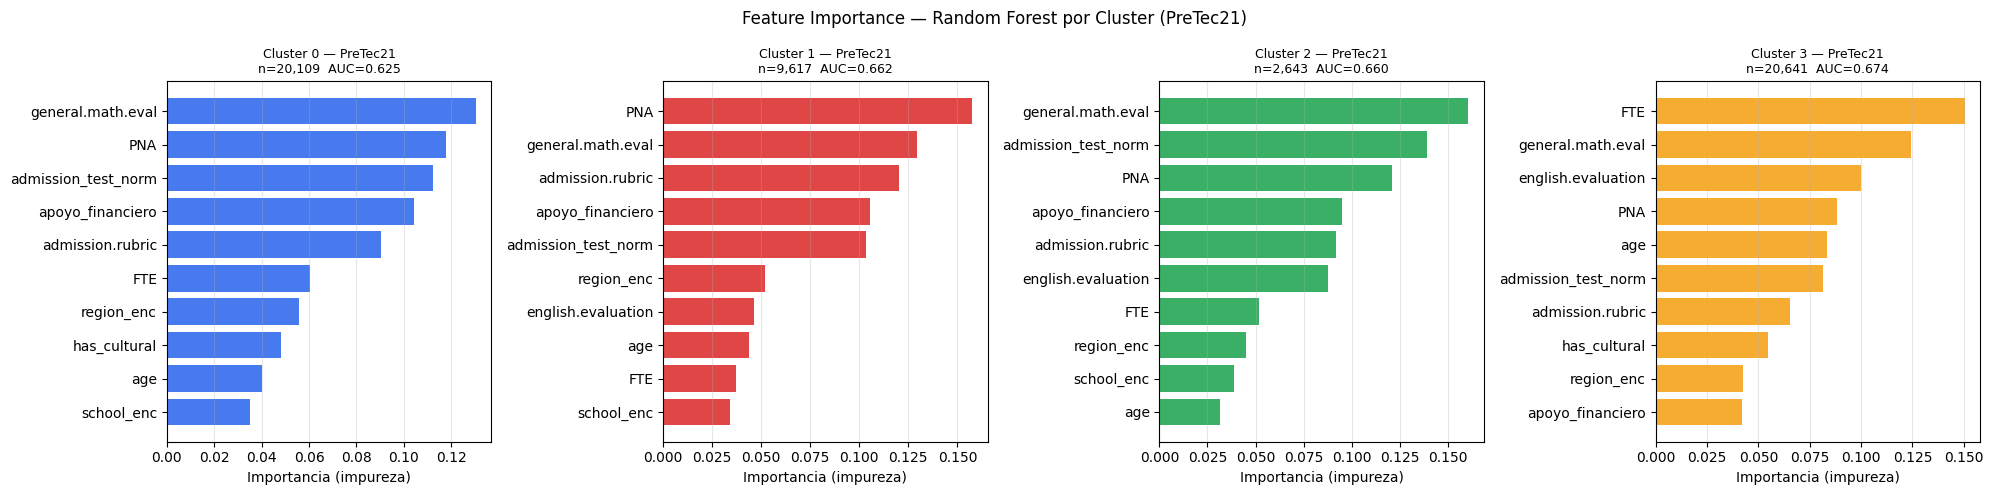

In [5]:
# Importancia por cluster — PreTec21
pre_rf = {k: v for (k, r), v in results_rf.items() if r == 'PreTec21'}
if pre_rf:
    fig, axes = plt.subplots(1, len(pre_rf), figsize=(5*len(pre_rf), 5))
    if len(pre_rf) == 1: axes = [axes]
    for ax, (cl_id, res) in zip(axes, sorted(pre_rf.items())):
        rf = res['trained_model']
        fi = pd.Series(rf.feature_importances_, index=res['feat_cols'])
        fi = fi.sort_values(ascending=False).head(10)
        ax.barh(fi.index, fi.values, color=CLUSTER_COLORS[cl_id], alpha=0.85)
        ax.invert_yaxis()
        ax.set_title(f'Cluster {cl_id} — PreTec21\n'
                     f'n={res["n_train"]+res["n_test"]:,}  AUC={res["auc"]:.3f}', fontsize=9)
        ax.set_xlabel('Importancia (impureza)'); ax.grid(axis='x', alpha=0.3)
    plt.suptitle('Feature Importance — Random Forest por Cluster (PreTec21)', fontsize=12)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'rf_importance_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. SHAP — Random Forest por cluster

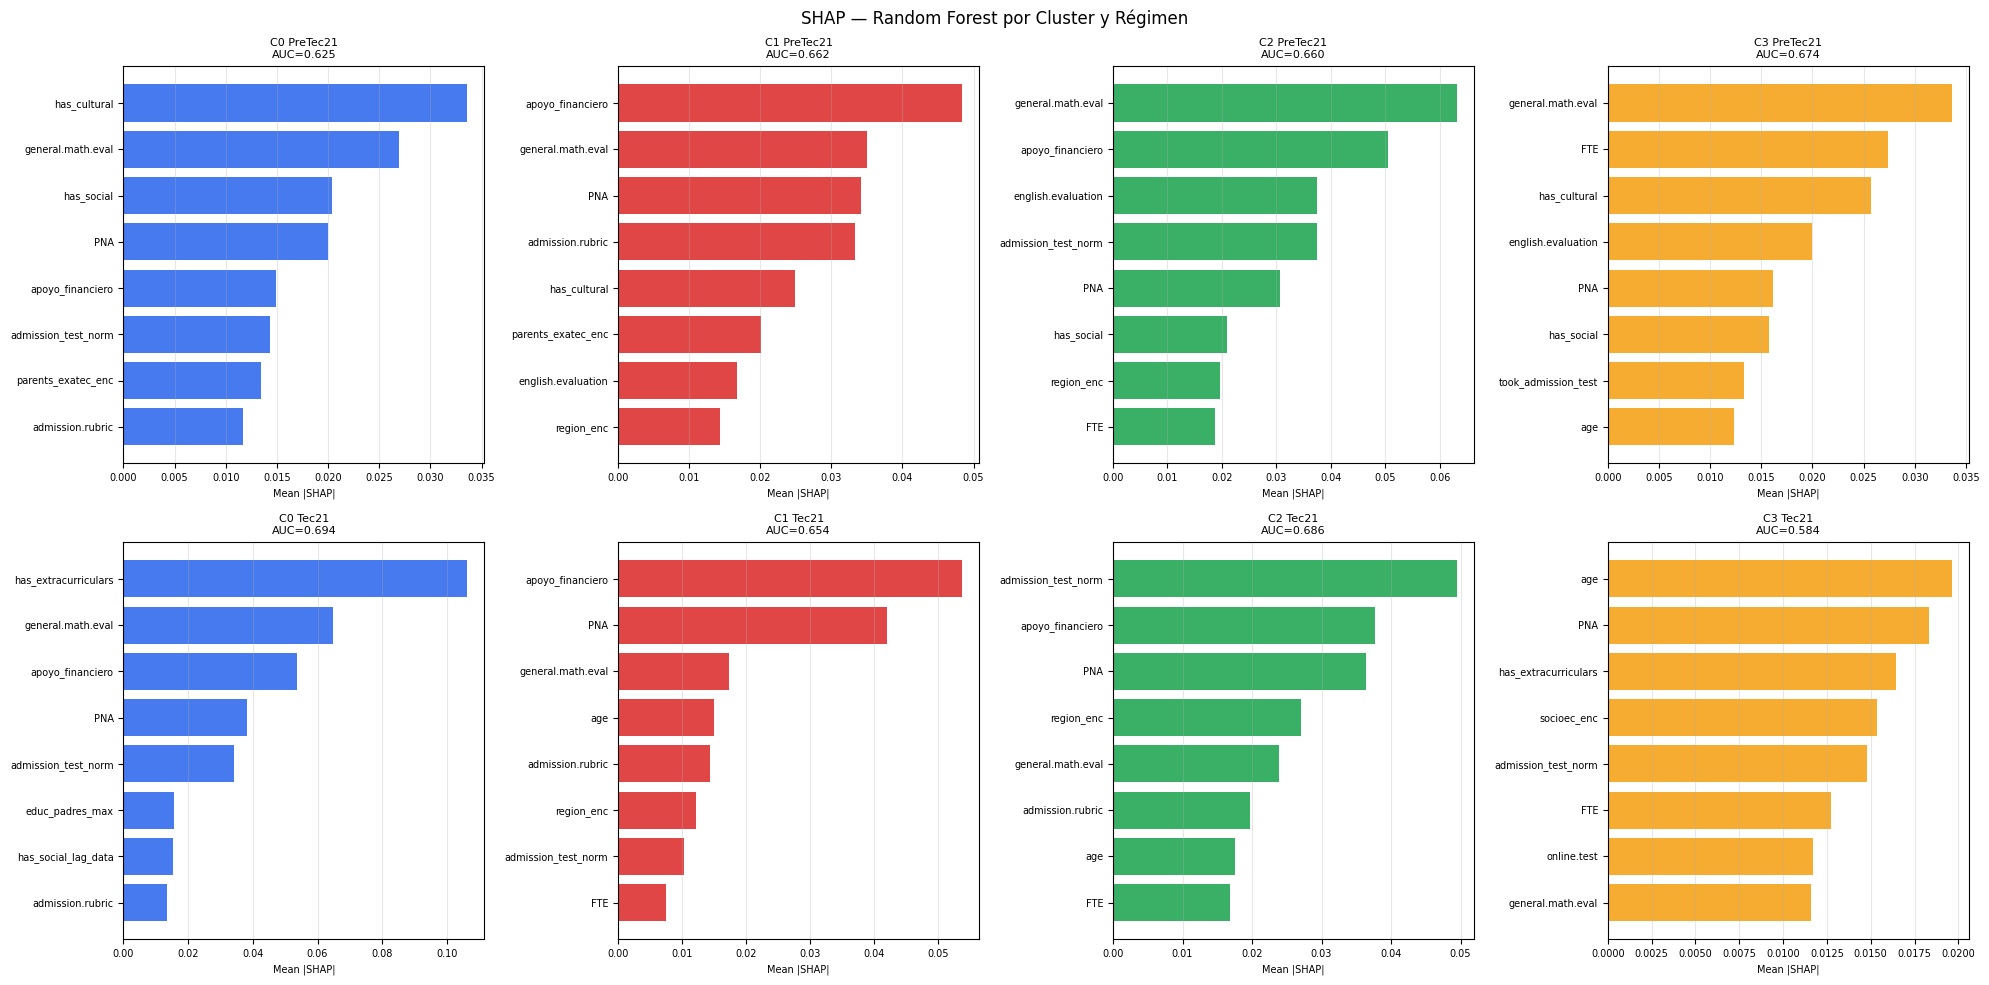

In [6]:
def get_shap_matrix(sv, cls=1):
    if isinstance(sv, list): return np.array(sv[cls] if len(sv)>cls else sv[0])
    a = np.array(sv)
    if a.ndim == 3: return a[:,:,cls]
    return a

if SHAP_AVAILABLE:
    n_cols = N_CLUSTERS
    fig, axes = plt.subplots(2, n_cols, figsize=(5*n_cols, 10))
    if n_cols == 1: axes = axes.reshape(2,1)

    for row_i, regime_name in enumerate(['PreTec21','Tec21']):
        for col_i, k in enumerate(range(N_CLUSTERS)):
            ax = axes[row_i, col_i]
            key = (k, regime_name)
            if key not in results_rf: ax.set_visible(False); continue
            res = results_rf[key]
            rf  = res['trained_model']
            X_cl, _, feat_cols, _ = get_cluster_data(k, regime_name)
            imp = SimpleImputer(strategy='median')
            X_cl = imp.fit_transform(X_cl)
            sample = X_cl[:min(300, len(X_cl))]
            exp  = shap.TreeExplainer(rf)
            sv   = get_shap_matrix(exp.shap_values(sample))
            mean_abs = np.abs(sv).mean(axis=0)
            top_idx = np.argsort(mean_abs)[::-1][:8]
            ax.barh([feat_cols[i] for i in top_idx], mean_abs[top_idx],
                    color=CLUSTER_COLORS[k], alpha=0.85)
            ax.invert_yaxis()
            ax.set_title(f'C{k} {regime_name}\nAUC={res["auc"]:.3f}', fontsize=8)
            ax.set_xlabel('Mean |SHAP|', fontsize=7)
            ax.tick_params(labelsize=7); ax.grid(axis='x', alpha=0.3)

    plt.suptitle('SHAP — Random Forest por Cluster y Régimen', fontsize=12)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'rf_shap_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("SHAP no disponible. pip install shap --break-system-packages")

## 5. Comparación de AUC: DT vs RF

In [7]:
comp_rows = []
for cl in range(N_CLUSTERS):
    for reg in ['PreTec21','Tec21']:
        key = (cl, reg)
        dt_auc = results_dt.get(key, {}).get('auc', np.nan)
        rf_auc = results_rf.get(key, {}).get('auc', np.nan)
        comp_rows.append({'Cluster':cl,'Régimen':reg,
                           'DT_AUC':round(dt_auc,3) if not np.isnan(dt_auc) else '-',
                           'RF_AUC':round(rf_auc,3) if not np.isnan(rf_auc) else '-'})
comp_df = pd.DataFrame(comp_rows)
print("DT vs RF — AUC por cluster y régimen:")
print(comp_df.to_string(index=False))

DT vs RF — AUC por cluster y régimen:
 Cluster  Régimen  DT_AUC  RF_AUC
       0 PreTec21   0.574   0.625
       0    Tec21   0.597   0.694
       1 PreTec21   0.611   0.662
       1    Tec21   0.623   0.654
       2 PreTec21   0.611   0.660
       2    Tec21   0.631   0.686
       3 PreTec21   0.614   0.674
       3    Tec21   0.506   0.584
